# Experiment SQ4 — Cross-Hardware Domain Gap
## USRP B200 → RTL-SDR V3 Performance Degradation

**SQ4:** How much does cross-hardware deployment (USRP B200 → RTL-SDR V3) degrade authentication accuracy?

| Sub-Exp | Name | Train data | Test data | Purpose |
|---------|------|-----------|----------|---------|
| D1 | Zero-shot transfer | Phase 1 model (USRP, no retraining) | RTL-SDR R4+R5 | **Primary SQ4 dAcc measurement** |
| D2 | RTL-SDR in-domain | RTL-SDR R1–R3 | RTL-SDR R4+R5 | Performance ceiling on RTL-SDR hardware |
| D3 | Feature analysis | — | Both | Mechanistic explanation of the gap |

**Capture parameters confirmed from GRC flowgraphs:**  
900 MHz · 1 Msps · TX gain 30 dB · RX RF/IF/BB gain 30/20/20 dB · AGC disabled · DC offset mode 0 · IQ balance mode 0 · fc32 format

---
**Run cells top to bottom.  
If the session crashes at any point, just re-run from Cell 1 — every cell is self-sufficient.**

## Cell 1 — Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Cell 2 — Imports, Constants, Paths, All Helper Functions
> **This cell contains everything.** Re-run it alone after any crash to restore the full environment.

In [ ]:
import os, glob, re, json, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE
from scipy.signal import welch
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.labelsize': 11})
sns.set_style('whitegrid')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE          = '/content/drive/MyDrive/My Thesis'
RTL_DATA_DIR  = f'{BASE}/Recordings/Recordings_RTL/RTL_Mod'
USRP_DATA_DIR = f'{BASE}/Recordings/Recordings_Mod'
MODEL_DIR     = f'{BASE}/Models'
OUT_DIR       = f'{BASE}/SQ4_Results'
FIG_DIR       = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
MODS       = ['BPSK', 'QPSK', 'GFSK', 'OOK']
DEVICES    = ['DEV01', 'DEV02']
TRAIN_REPS = [1, 2, 3]
TEST_REPS  = [4, 5]
WIN_SIZE   = 128
TRANSIENT  = 100_000
SNR_LEVELS = [None, 20, 10, 0]
SNR_LABELS = ['Clean', 'SNR 20 dB', 'SNR 10 dB', 'SNR 0 dB']
LABEL_MAP  = {'DEV01': 0, 'DEV02': 1}
SAMP_RATE  = 1e6

# Phase 1 USRP reference accuracies (from thesis Ch4, Experiment B heatmap)
PHASE1_ACC = {
    'BPSK': {'Clean':100.0,'SNR 20 dB':100.0,'SNR 10 dB':100.0,'SNR 0 dB':99.9},
    'QPSK': {'Clean':100.0,'SNR 20 dB':99.7, 'SNR 10 dB':98.2, 'SNR 0 dB':97.9},
    'GFSK': {'Clean':100.0,'SNR 20 dB':100.0,'SNR 10 dB':99.9, 'SNR 0 dB':98.4},
    'OOK':  {'Clean':70.5, 'SNR 20 dB':70.5, 'SNR 10 dB':70.3, 'SNR 0 dB':64.9},
}

# ── Helper: add AWGN ───────────────────────────────────────────────────────
def add_awgn(X, snr_db):
    if snr_db is None:
        return X
    sig_power = np.mean(X ** 2)
    noise_std = np.sqrt(sig_power / (2.0 * 10 ** (snr_db / 10.0)))
    return X + np.random.normal(0, noise_std, X.shape).astype(np.float32)

# ── Helper: load windows from one file (memory-safe) ──────────────────────
def load_windows(fpath):
    """Load, drop transient, normalise, segment → (N,128,2) float32."""
    iq = np.fromfile(fpath, dtype=np.complex64)[TRANSIENT:]
    peak = np.max(np.abs(iq))
    if peak > 0:
        iq /= peak
    n = len(iq) // WIN_SIZE
    iq = iq[:n * WIN_SIZE].reshape(n, WIN_SIZE)
    return np.stack([iq.real, iq.imag], axis=-1).astype(np.float32)

# ── Helper: evaluate model across a list of file-rows ─────────────────────
def evaluate_from_files(model, file_rows, snr_db=None, batch_size=1024):
    """
    Evaluate binary CNN file-by-file (no large arrays in RAM).
    file_rows: list of dicts with keys 'file' and 'label'.
    Returns dict of accuracy, FAR, FRR, AUC, confusion matrix.
    """
    all_probs, all_labels = [], []
    for row in file_rows:
        X = load_windows(row['file'])
        if snr_db is not None:
            X = add_awgn(X, snr_db)
        probs = model.predict(X, batch_size=batch_size, verbose=0)[:, 1]
        all_probs.append(probs)
        all_labels.append(np.full(len(X), row['label'], dtype=np.int32))
        del X, probs; gc.collect()
    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    y_pred = (probs >= 0.5).astype(int)
    acc    = accuracy_score(labels, y_pred) * 100
    cm     = confusion_matrix(labels, y_pred)
    far = (y_pred[labels==0]==1).mean()*100 if (labels==0).any() else np.nan
    frr = (y_pred[labels==1]==0).mean()*100 if (labels==1).any() else np.nan
    fpr, tpr, _ = roc_curve(labels, probs)
    return {'accuracy': round(acc,2), 'far': round(far,3), 'frr': round(frr,3),
            'auc': round(auc(fpr,tpr),4), 'cm': cm,
            'n': len(labels), 'labels': labels, 'probs': probs}

# ── Helper: get file-row list from manifest ────────────────────────────────
def get_file_rows(df, devices, mods, reps):
    rows = []
    for mod in mods:
        for dev in devices:
            for rep in reps:
                sel = df[(df.device==dev)&(df.modulation==mod)&(df.rep==rep)]
                if not sel.empty:
                    rows.append({'file': sel.iloc[0]['file'],
                                 'label': LABEL_MAP[dev],
                                 'device': dev, 'modulation': mod, 'rep': rep})
    return rows

# ── CNN architecture (identical to Phase 1 Model 3) ───────────────────────
def build_1d_cnn(input_shape=(128,2), n_classes=2):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(32,3,padding='same',activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.AveragePooling1D(2)(x)
    x = layers.Conv1D(64,3,padding='same',activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.AveragePooling1D(2)(x)
    x = layers.Conv1D(64,3,padding='same',activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.AveragePooling1D(2)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu', name='embedding')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    m = Model(inputs=inp, outputs=out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

print('All imports, constants, and helpers ready.')
print(f'  RTL data  : {RTL_DATA_DIR}')
print(f'  Models    : {MODEL_DIR}')
print(f'  Output    : {OUT_DIR}')

All imports, constants, and helpers ready.
  RTL data  : /content/drive/MyDrive/My Thesis/Recordings/Recordings_RTL/RTL_Mod
  Models    : /content/drive/MyDrive/My Thesis/Models
  Output    : /content/drive/MyDrive/My Thesis/SQ4_Results


## Cell 3 — Build File Manifest

In [ ]:
pattern = re.compile(r'(DEV0[12])_(BPSK|QPSK|GFSK|OOK)_(S\d+)_(R\d+)_RTL\.dat$')
manifest = []
for fpath in sorted(glob.glob(os.path.join(RTL_DATA_DIR, '*.dat'))):
    m = pattern.match(os.path.basename(fpath))
    if m:
        dev, mod, sess, rep = m.groups()
        n_samp = os.path.getsize(fpath) // 8
        manifest.append({'file': fpath, 'device': dev, 'modulation': mod,
                          'rep': int(rep[-1]),
                          'n_windows': max(0,(n_samp-TRANSIENT)//WIN_SIZE),
                          'size_mb': round(os.path.getsize(fpath)/1e6,1)})
    else:
        print(f'WARNING — unmatched file: {os.path.basename(fpath)}')

df_manifest = pd.DataFrame(manifest)
print(f'Found {len(df_manifest)} files  (expected {len(MODS)*len(DEVICES)*5})')
print()
print(df_manifest.groupby(['device','modulation'])[['n_windows','size_mb']]
      .sum().unstack('modulation').to_string())

test_rows  = get_file_rows(df_manifest, DEVICES, MODS, TEST_REPS)
train_rows = get_file_rows(df_manifest, DEVICES, MODS, TRAIN_REPS)
print(f'\nTest  file-rows : {len(test_rows)}')
print(f'Train file-rows : {len(train_rows)}')

Found 40 files  (expected 40)

           n_windows                         size_mb                     
modulation      BPSK    GFSK     OOK    QPSK    BPSK   GFSK    OOK   QPSK
device                                                                   
DEV01         855412  771531  827680  893198   879.9  794.1  851.5  918.7
DEV02         770895  853275  712968  850209   793.5  877.8  734.1  874.6

Test  file-rows : 16
Train file-rows : 24


## Cell 4 — Load Phase 1 Models

In [ ]:
# B1_combined_model = multi-modulation noise-augmented model (primary for SQ4)
# best_model_augmented = BPSK-only noise-augmented Model 3 (used for BPSK cross-check)

MODEL_B1  = os.path.join(MODEL_DIR, 'ExperimentB/B1_combined_model.keras')
MODEL_M3  = os.path.join(MODEL_DIR, 'ExperimentA/best_model_augmented.keras')

model_b1 = keras.models.load_model(MODEL_B1)
model_m3 = keras.models.load_model(MODEL_M3)

print(f'B1 (multi-mod)  loaded — {model_b1.count_params():,} params')
print(f'M3 (BPSK only)  loaded — {model_m3.count_params():,} params')

B1 (multi-mod)  loaded — 43,874 params
M3 (BPSK only)  loaded — 43,874 params


## Cell 5 — D1: Zero-Shot Transfer (Primary SQ4 Answer)
> Model B1 was trained entirely on USRP B200 data. We now evaluate it directly on RTL-SDR recordings
> with no retraining. Files are loaded one at a time to avoid OOM crashes.

In [ ]:
print('=== D1: Zero-Shot Transfer — Per Modulation × Per SNR ===')
d1_per_mod = {}

for mod in MODS:
    mod_rows = [r for r in test_rows if r['modulation'] == mod]
    d1_per_mod[mod] = []
    for snr_db, snr_label in zip(SNR_LEVELS, SNR_LABELS):
        res = evaluate_from_files(model_b1, mod_rows, snr_db)
        res['snr_label'] = snr_label
        d1_per_mod[mod].append(res)
    accs = [r['accuracy'] for r in d1_per_mod[mod]]
    print(f'  {mod}: ' + ' | '.join(f'{l}={a:.1f}%'
          for l,a in zip(SNR_LABELS, accs)))
    gc.collect()

print('\nD1 complete.')

=== D1: Zero-Shot Transfer — Per Modulation × Per SNR ===
  BPSK: Clean=49.4% | SNR 20 dB=49.4% | SNR 10 dB=49.4% | SNR 0 dB=49.4%
  QPSK: Clean=71.7% | SNR 20 dB=71.6% | SNR 10 dB=70.8% | SNR 0 dB=64.1%
  GFSK: Clean=27.9% | SNR 20 dB=27.9% | SNR 10 dB=28.4% | SNR 0 dB=32.6%
  OOK: Clean=49.8% | SNR 20 dB=49.8% | SNR 10 dB=49.7% | SNR 0 dB=47.6%

D1 complete.


## Cell 6 — Domain Gap Table (dAcc)

In [ ]:
gap_rows = []
for mod in MODS:
    for i, snr_label in enumerate(SNR_LABELS):
        acc_usrp = PHASE1_ACC[mod][snr_label]
        acc_rtl  = d1_per_mod[mod][i]['accuracy']
        gap_rows.append({'Modulation': mod, 'SNR': snr_label,
                          'Acc_USRP': acc_usrp, 'Acc_RTL_D1': acc_rtl,
                          'dAcc': round(acc_usrp - acc_rtl, 2)})

df_gap = pd.DataFrame(gap_rows)
df_gap.to_csv(os.path.join(OUT_DIR, 'dAcc_domain_gap_table.csv'), index=False)

print('=== DOMAIN GAP: dAcc = Acc(USRP) − Acc(RTL zero-shot) ===')
print(df_gap.to_string(index=False))

clean_gaps = df_gap[df_gap['SNR']=='Clean']
print(f'\nMean dAcc at Clean: {clean_gaps["dAcc"].mean():+.2f} pp')
print('Saved: dAcc_domain_gap_table.csv')

=== DOMAIN GAP: dAcc = Acc(USRP) − Acc(RTL zero-shot) ===
Modulation       SNR  Acc_USRP  Acc_RTL_D1  dAcc
      BPSK     Clean     100.0       49.41 50.59
      BPSK SNR 20 dB     100.0       49.41 50.59
      BPSK SNR 10 dB     100.0       49.39 50.61
      BPSK  SNR 0 dB      99.9       49.40 50.50
      QPSK     Clean     100.0       71.66 28.34
      QPSK SNR 20 dB      99.7       71.56 28.14
      QPSK SNR 10 dB      98.2       70.84 27.36
      QPSK  SNR 0 dB      97.9       64.08 33.82
      GFSK     Clean     100.0       27.89 72.11
      GFSK SNR 20 dB     100.0       27.94 72.06
      GFSK SNR 10 dB      99.9       28.36 71.54
      GFSK  SNR 0 dB      98.4       32.62 65.78
       OOK     Clean      70.5       49.78 20.72
       OOK SNR 20 dB      70.5       49.77 20.73
       OOK SNR 10 dB      70.3       49.68 20.62
       OOK  SNR 0 dB      64.9       47.63 17.27

Mean dAcc at Clean: +42.94 pp
Saved: dAcc_domain_gap_table.csv


## Cell 7 — Figures: dAcc Heatmap + Accuracy-SNR Curves

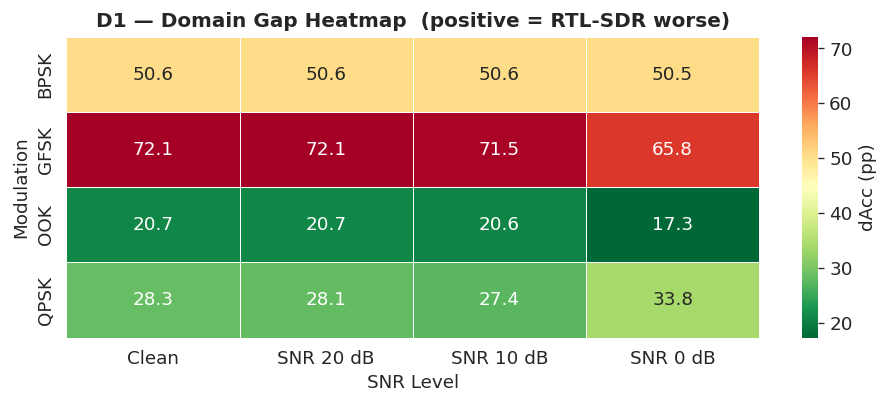

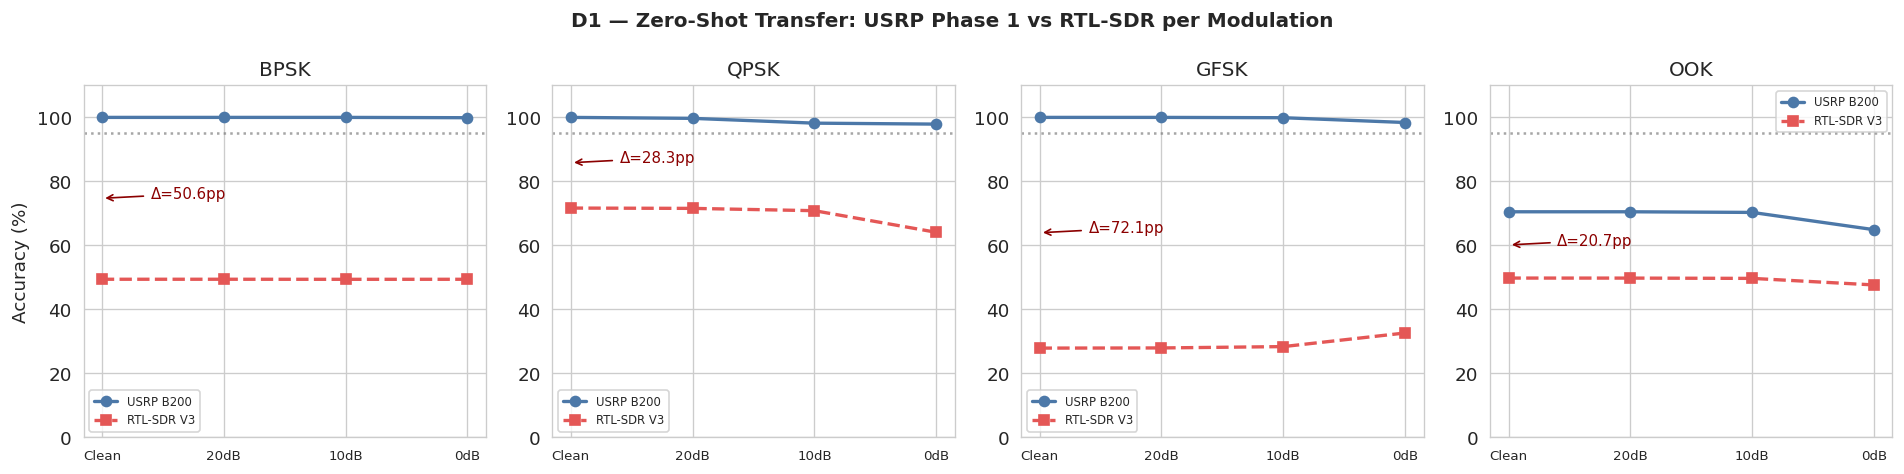

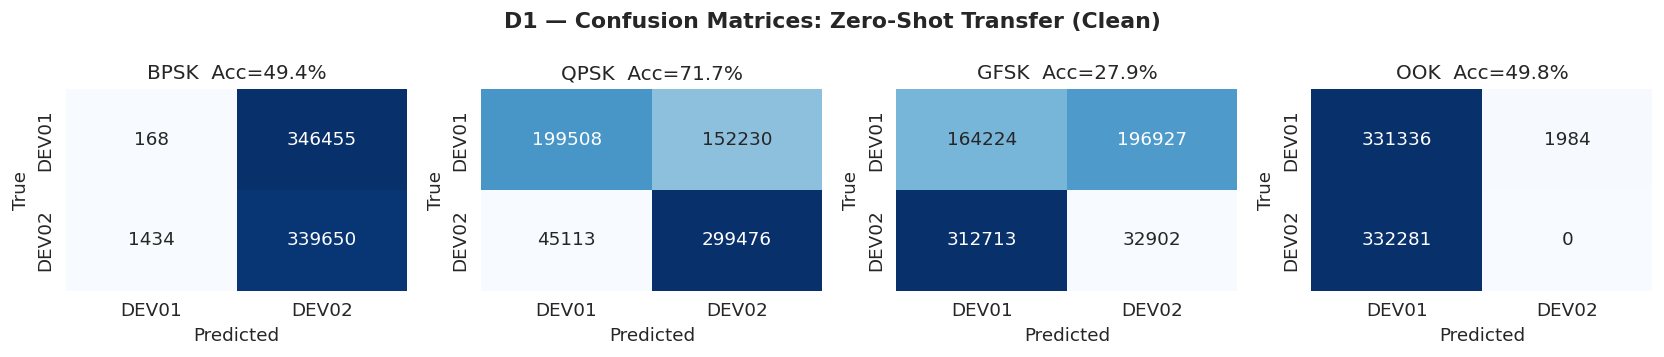

D1 figures saved.


In [ ]:
# ── dAcc heatmap ──────────────────────────────────────────────────────────
pivot = df_gap.pivot(index='Modulation', columns='SNR', values='dAcc')[SNR_LABELS]
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'dAcc (pp)'})
ax.set_title('D1 — Domain Gap Heatmap  (positive = RTL-SDR worse)', fontweight='bold')
ax.set_xlabel('SNR Level'); ax.set_ylabel('Modulation')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/D1_dacc_heatmap.pdf', bbox_inches='tight'); plt.show()

# ── Accuracy-SNR curves per modulation ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
fig.suptitle('D1 — Zero-Shot Transfer: USRP Phase 1 vs RTL-SDR per Modulation',
             fontsize=12, fontweight='bold')
for ax, mod in zip(axes, MODS):
    acc_u = [PHASE1_ACC[mod][l] for l in SNR_LABELS]
    acc_r = [r['accuracy'] for r in d1_per_mod[mod]]
    x = range(len(SNR_LABELS))
    ax.plot(x, acc_u, 'o-', color='#4C78A8', lw=2, ms=6, label='USRP B200')
    ax.plot(x, acc_r, 's--', color='#E45756', lw=2, ms=6, label='RTL-SDR V3')
    gap = acc_u[0] - acc_r[0]
    ax.annotate(f'Δ={gap:.1f}pp', xy=(0, (acc_u[0]+acc_r[0])/2),
                xytext=(0.4, (acc_u[0]+acc_r[0])/2),
                fontsize=9, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred'))
    ax.axhline(95, color='gray', ls=':', alpha=0.7)
    ax.set_title(mod); ax.set_ylim(0, 110)
    ax.set_xticks(x)
    ax.set_xticklabels(['Clean','20dB','10dB','0dB'], fontsize=8)
    ax.set_ylabel('Accuracy (%)' if ax is axes[0] else '')
    ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/D1_accuracy_snr_curves.pdf', bbox_inches='tight'); plt.show()

# ── Confusion matrices (Clean) ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
fig.suptitle('D1 — Confusion Matrices: Zero-Shot Transfer (Clean)', fontweight='bold')
for ax, mod in zip(axes, MODS):
    cm = d1_per_mod[mod][0]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['DEV01','DEV02'], yticklabels=['DEV01','DEV02'])
    ax.set_title(f'{mod}  Acc={d1_per_mod[mod][0]["accuracy"]:.1f}%')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/D1_confusion_matrices.pdf', bbox_inches='tight'); plt.show()
print('D1 figures saved.')

## Cell 8 — D2: Train RTL-SDR In-Domain Model
> Fresh 1D CNN (same architecture) trained on RTL-SDR R1–R3, tested on R4–R5.
> Data is augmented with AWGN and loaded in small batches to stay within RAM.
> **Limitation:** within-session split only (one recording day). Results are an optimistic upper bound.

In [ ]:
# Quick sanity check — confirms all variables are live before long training run
assert 'df_manifest' in dir() and 'd1_per_mod' in dir() and 'model_b1' in dir(), \
    "Session state incomplete — re-run Cells 1-6 first"
assert len(train_rows) > 0, "train_rows is empty"
print(f"State OK — {len(train_rows)} train files, {len(test_rows)} test files")

# ── Cell 8 — D2: Train RTL-SDR In-Domain Model (tf.data generator, no OOM) ──

import tensorflow as tf

def make_rtl_dataset(file_rows, win_size=WIN_SIZE, transient=TRANSIENT,
                     snr_augment=True, batch_size=512, shuffle_buf=20_000):
    """
    tf.data pipeline: loads one file at a time, augments with AWGN on GPU,
    never materialises the full training array in RAM.
    """
    def load_and_segment(fpath_bytes, label):
        # Pure-Python file loader wrapped in tf.py_function
        fpath = fpath_bytes.numpy().decode()
        iq    = np.fromfile(fpath, dtype=np.complex64)[transient:]
        peak  = np.max(np.abs(iq))
        if peak > 0:
            iq /= peak
        n = len(iq) // win_size
        iq = iq[:n * win_size].reshape(n, win_size)
        X  = np.stack([iq.real, iq.imag], axis=-1).astype(np.float32)
        y  = np.full(n, label, dtype=np.int32)
        return X, y

    def tf_load(fpath, label):
        X, y = tf.py_function(load_and_segment, [fpath, label],
                               [tf.float32, tf.int32])
        X.set_shape([None, win_size, 2])
        y.set_shape([None])
        return tf.data.Dataset.from_tensor_slices((X, y))

    def awgn_aug(x, y):
        """Random SNR in {0,10,20,None} applied per-batch."""
        snr_db = tf.random.shuffle(tf.constant([0.0,10.0,20.0,100.0]))[0]
        sig_power = tf.reduce_mean(tf.square(x))
        # snr=100 → effectively clean
        noise_std = tf.sqrt(sig_power / (2.0 * tf.pow(10.0, snr_db / 10.0)))
        noise = tf.random.normal(tf.shape(x), stddev=noise_std)
        return x + noise, y

    fpaths = [r['file']  for r in file_rows]
    labels = [r['label'] for r in file_rows]

    file_ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(fpaths), tf.constant(labels, dtype=tf.int32))
    )
    # flat_map: each file → its windows as individual examples
    ds = file_ds.flat_map(tf_load)

    if snr_augment:
        ds = ds.map(awgn_aug, num_parallel_calls=tf.data.AUTOTUNE)

    ds = (ds.shuffle(shuffle_buf)
            .batch(batch_size, drop_remainder=False)
            .prefetch(tf.data.AUTOTUNE))
    return ds


# Build train and val datasets (no arrays in RAM at all)
# Val = last rep of each mod/dev from train_rows
val_rows   = [r for r in train_rows if r['rep'] == 3]
fit_rows   = [r for r in train_rows if r['rep'] != 3]

print(f'Fit  rows: {len(fit_rows)}  (R1+R2)')
print(f'Val  rows: {len(val_rows)}  (R3)')

ds_train = make_rtl_dataset(fit_rows,  snr_augment=True,  batch_size=512)
ds_val   = make_rtl_dataset(val_rows,  snr_augment=False, batch_size=512)

# Count steps (approximate — needed for fit())
def count_windows(rows):
    total = 0
    for r in rows:
        n = (os.path.getsize(r['file'])//8 - TRANSIENT) // WIN_SIZE
        total += max(0, n)
    return total

n_fit = count_windows(fit_rows)
n_val = count_windows(val_rows)
steps_per_epoch = max(1, n_fit // 512)
val_steps       = max(1, n_val // 512)
print(f'Approx windows — fit: {n_fit:,}  val: {n_val:,}')
print(f'Steps per epoch: {steps_per_epoch}  |  Val steps: {val_steps}')

# Train
model_d2   = build_1d_cnn()
history_d2 = model_d2.fit(
    ds_train,
    validation_data=ds_val,
    epochs=60,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6, verbose=1)
    ],
    verbose=2
)
print('D2 training complete.')

State OK — 24 train files, 16 test files
Fit  rows: 16  (R1+R2)
Val  rows: 8  (R3)
Approx windows — fit: 2,406,503  val: 1,372,264
Steps per epoch: 4700  |  Val steps: 2680
Epoch 1/60
4700/4700 - 259s - 55ms/step - accuracy: 0.9959 - loss: 0.0215 - val_accuracy: 0.6020 - val_loss: 5.7578 - learning_rate: 0.0010
Epoch 2/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


4700/4700 - 20s - 4ms/step - accuracy: 1.0000 - loss: 4.2954e-04 - val_accuracy: 0.6020 - val_loss: 5.7586 - learning_rate: 0.0010
Epoch 3/60
4700/4700 - 215s - 46ms/step - accuracy: 0.9875 - loss: 0.0529 - val_accuracy: 0.5099 - val_loss: 6.6311 - learning_rate: 0.0010
Epoch 4/60
4700/4700 - 18s - 4ms/step - accuracy: 1.0000 - loss: 3.9952e-04 - val_accuracy: 0.5099 - val_loss: 6.6338 - learning_rate: 0.0010
Epoch 5/60

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4700/4700 - 217s - 46ms/step - accuracy: 0.9852 - loss: 0.0585 - val_accuracy: 0.5681 - val_loss: 7.2189 - learning_rate: 0.0010
Epoch 6/60
4700/4700 - 19s - 4ms/step - accuracy: 1.0000 - loss: 6.0695e-04 - val_accuracy: 0.5681 - val_loss: 7.2213 - learning_rate: 5.0000e-04
Epoch 7/60
4700/4700 - 210s - 45ms/step - accuracy: 0.9597 - loss: 0.1186 - val_accuracy: 0.6094 - val_loss: 4.7948 - learning_rate: 5.0000e-04
Epoch 8/60
4700/4700 - 19s - 4ms/step - accuracy: 1.0000 - loss: 0.0029 - val_ac

In [ ]:
# ── Cell 8 — D2: Train RTL-SDR In-Domain Model (RAM-capped, no OOM) ──────────
# Load at most MAX_WIN windows per file. 5000 × 24 files × 4 aug copies ≈ 480K
# windows ≈ 480K × 128 × 2 × 4 bytes ≈ 490 MB — well within Colab RAM.

MAX_WIN = 5000  # windows per file (increase to 8000 if RAM allows)

print('Building D2 training set (capped at', MAX_WIN, 'windows per file)...')
parts_X, parts_y = [], []

for row in train_rows:
    iq   = np.fromfile(row['file'], dtype=np.complex64)[TRANSIENT:]
    peak = np.max(np.abs(iq))
    if peak > 0:
        iq /= peak
    n = min(len(iq) // WIN_SIZE, MAX_WIN)
    iq = iq[:n * WIN_SIZE].reshape(n, WIN_SIZE)
    X  = np.stack([iq.real, iq.imag], axis=-1).astype(np.float32)
    y  = np.full(n, row['label'], dtype=np.int32)
    del iq; gc.collect()

    parts_X.append(X)                         # clean
    parts_y.append(y)
    for snr in [0, 10, 20]:                   # three noise levels
        parts_X.append(add_awgn(X, snr))
        parts_y.append(y)
    del X; gc.collect()

X_tr = np.concatenate(parts_X)
y_tr = np.concatenate(parts_y)
del parts_X, parts_y; gc.collect()

# Shuffle
idx  = np.random.permutation(len(X_tr))
X_tr, y_tr = X_tr[idx], y_tr[idx]
print(f'Training set: {X_tr.shape}  labels: {np.bincount(y_tr)}')
print(f'RAM used:     ~{X_tr.nbytes / 1e6:.0f} MB')

# Train
model_d2   = build_1d_cnn()
history_d2 = model_d2.fit(
    X_tr, y_tr,
    validation_split=0.15,
    epochs=80,
    batch_size=512,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1)
    ],
    verbose=2
)
del X_tr, y_tr; gc.collect()
print('D2 training complete.')

Building D2 training set (capped at 5000 windows per file)...
Training set: (480000, 128, 2)  labels: [240000 240000]
RAM used:     ~492 MB
Epoch 1/80
797/797 - 23s - 28ms/step - accuracy: 0.9523 - loss: 0.1198 - val_accuracy: 0.9718 - val_loss: 0.0752 - learning_rate: 0.0010
Epoch 2/80
797/797 - 9s - 11ms/step - accuracy: 0.9769 - loss: 0.0629 - val_accuracy: 0.9798 - val_loss: 0.0540 - learning_rate: 0.0010
Epoch 3/80
797/797 - 9s - 11ms/step - accuracy: 0.9806 - loss: 0.0534 - val_accuracy: 0.9823 - val_loss: 0.0468 - learning_rate: 0.0010
Epoch 4/80
797/797 - 9s - 11ms/step - accuracy: 0.9822 - loss: 0.0488 - val_accuracy: 0.9842 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 5/80
797/797 - 9s - 11ms/step - accuracy: 0.9833 - loss: 0.0450 - val_accuracy: 0.9809 - val_loss: 0.0485 - learning_rate: 0.0010
Epoch 6/80
797/797 - 9s - 11ms/step - accuracy: 0.9847 - loss: 0.0422 - val_accuracy: 0.9825 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 7/80
797/797 - 9s - 11ms/step - accur

## Cell 9 — D2: Evaluate In-Domain Model

=== D2: RTL-SDR In-Domain Results ===
  BPSK: Clean=99.5% | SNR 20 dB=99.5% | SNR 10 dB=99.5% | SNR 0 dB=98.9%
  QPSK: Clean=91.3% | SNR 20 dB=91.2% | SNR 10 dB=90.8% | SNR 0 dB=84.5%
  GFSK: Clean=99.9% | SNR 20 dB=99.9% | SNR 10 dB=99.8% | SNR 0 dB=98.8%
  OOK: Clean=96.4% | SNR 20 dB=96.4% | SNR 10 dB=96.6% | SNR 0 dB=95.0%


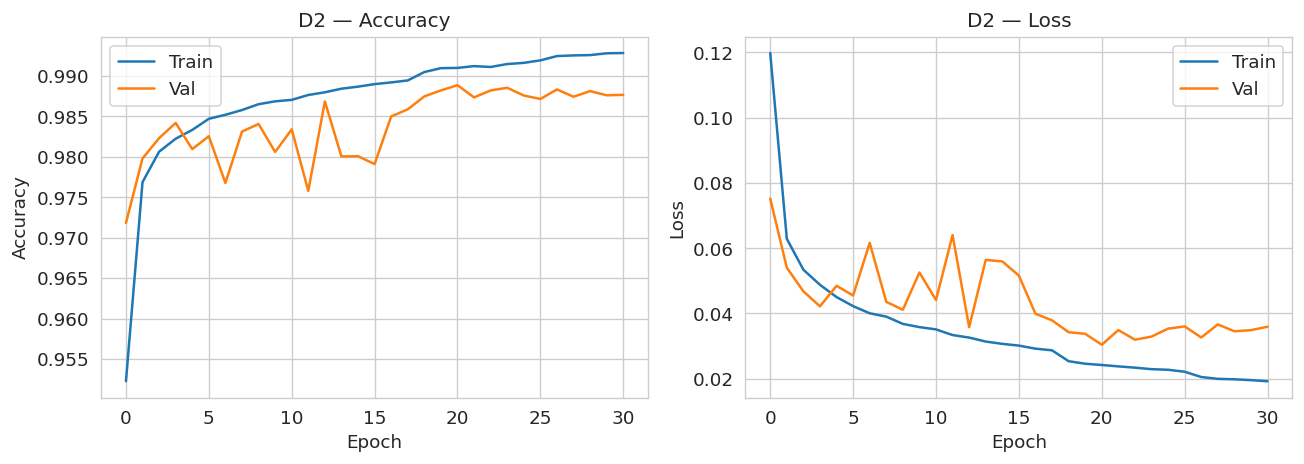

In [ ]:
print('=== D2: RTL-SDR In-Domain Results ===')
d2_per_mod = {}

for mod in MODS:
    mod_rows = [r for r in test_rows if r['modulation'] == mod]
    d2_per_mod[mod] = []
    for snr_db, snr_label in zip(SNR_LEVELS, SNR_LABELS):
        res = evaluate_from_files(model_d2, mod_rows, snr_db)
        res['snr_label'] = snr_label
        d2_per_mod[mod].append(res)
    accs = [r['accuracy'] for r in d2_per_mod[mod]]
    print(f'  {mod}: ' + ' | '.join(f'{l}={a:.1f}%'
          for l,a in zip(SNR_LABELS, accs)))
    gc.collect()

# Training curve
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(11,4))
ax1.plot(history_d2.history['accuracy'],    label='Train')
ax1.plot(history_d2.history['val_accuracy'],label='Val')
ax1.set_title('D2 — Accuracy'); ax1.set_ylabel('Accuracy'); ax1.legend()
ax2.plot(history_d2.history['loss'],    label='Train')
ax2.plot(history_d2.history['val_loss'],label='Val')
ax2.set_title('D2 — Loss'); ax2.set_ylabel('Loss'); ax2.legend()
for ax in (ax1,ax2): ax.set_xlabel('Epoch')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/D2_training_curve.pdf', bbox_inches='tight'); plt.show()

## Cell 10 — Three-Way Comparison Table + Heatmaps

Modulation       SNR  USRP_Phase1  RTL_ZeroShot_D1  RTL_InDomain_D2  dAcc_D1  RecoverableGap_D2_D1
      BPSK     Clean        100.0            49.41            99.52    50.59                 50.11
      BPSK SNR 20 dB        100.0            49.41            99.52    50.59                 50.11
      BPSK SNR 10 dB        100.0            49.39            99.53    50.61                 50.14
      BPSK  SNR 0 dB         99.9            49.40            98.93    50.50                 49.53
      QPSK     Clean        100.0            71.66            91.27    28.34                 19.61
      QPSK SNR 20 dB         99.7            71.56            91.23    28.14                 19.67
      QPSK SNR 10 dB         98.2            70.84            90.78    27.36                 19.94
      QPSK  SNR 0 dB         97.9            64.08            84.54    33.82                 20.46
      GFSK     Clean        100.0            27.89            99.88    72.11                 71.99
      GFSK

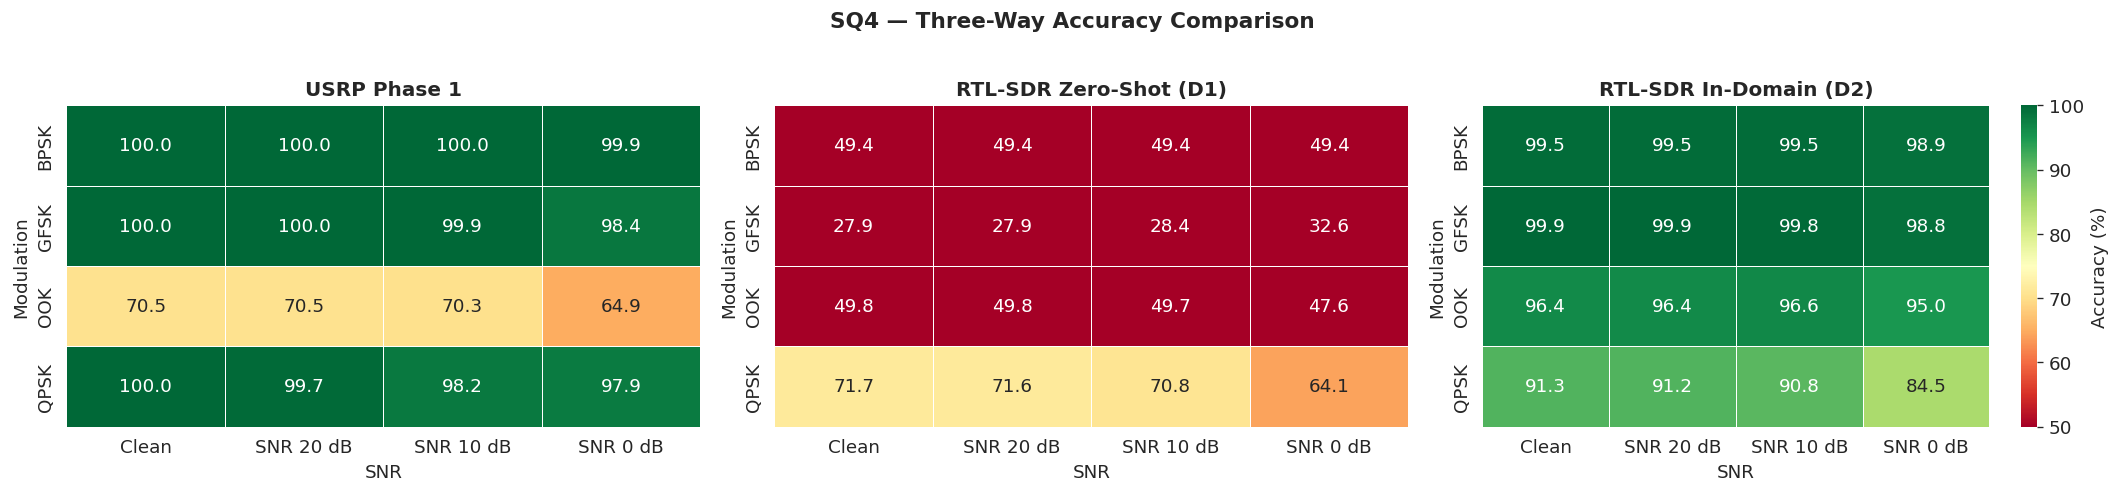

Saved: SQ4_comparison_table.csv  |  SQ4_three_way_heatmaps.pdf


In [ ]:
comp_rows = []
for mod in MODS:
    for i, snr_label in enumerate(SNR_LABELS):
        a_usrp = PHASE1_ACC[mod][snr_label]
        a_d1   = d1_per_mod[mod][i]['accuracy']
        a_d2   = d2_per_mod[mod][i]['accuracy']
        comp_rows.append({'Modulation': mod, 'SNR': snr_label,
                           'USRP_Phase1': a_usrp,
                           'RTL_ZeroShot_D1': a_d1,
                           'RTL_InDomain_D2': a_d2,
                           'dAcc_D1': round(a_usrp - a_d1, 2),
                           'RecoverableGap_D2_D1': round(a_d2 - a_d1, 2)})

df_comp = pd.DataFrame(comp_rows)
df_comp.to_csv(os.path.join(OUT_DIR,'SQ4_comparison_table.csv'), index=False)
print(df_comp.to_string(index=False))

# Three-way heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
titles = ['USRP Phase 1','RTL-SDR Zero-Shot (D1)','RTL-SDR In-Domain (D2)']
keys   = ['USRP_Phase1','RTL_ZeroShot_D1','RTL_InDomain_D2']
for ax, title, key in zip(axes, titles, keys):
    piv = df_comp.pivot(index='Modulation',columns='SNR',values=key)[SNR_LABELS]
    sns.heatmap(piv, annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=50, vmax=100, linewidths=0.5, ax=ax,
                cbar=(ax is axes[-1]),
                cbar_kws={'label':'Accuracy (%)'})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('SNR'); ax.set_ylabel('Modulation')
fig.suptitle('SQ4 — Three-Way Accuracy Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/SQ4_three_way_heatmaps.pdf', bbox_inches='tight'); plt.show()
print('Saved: SQ4_comparison_table.csv  |  SQ4_three_way_heatmaps.pdf')

## Cell 11 — D3: Feature Distribution Analysis (CFO + RMS)
> Compares the statistical fingerprint features of the same USRP transmitters received
> by USRP B200 vs RTL-SDR V3. Explains *why* the domain gap exists at the feature level.

Features extracted for 16 file combinations.


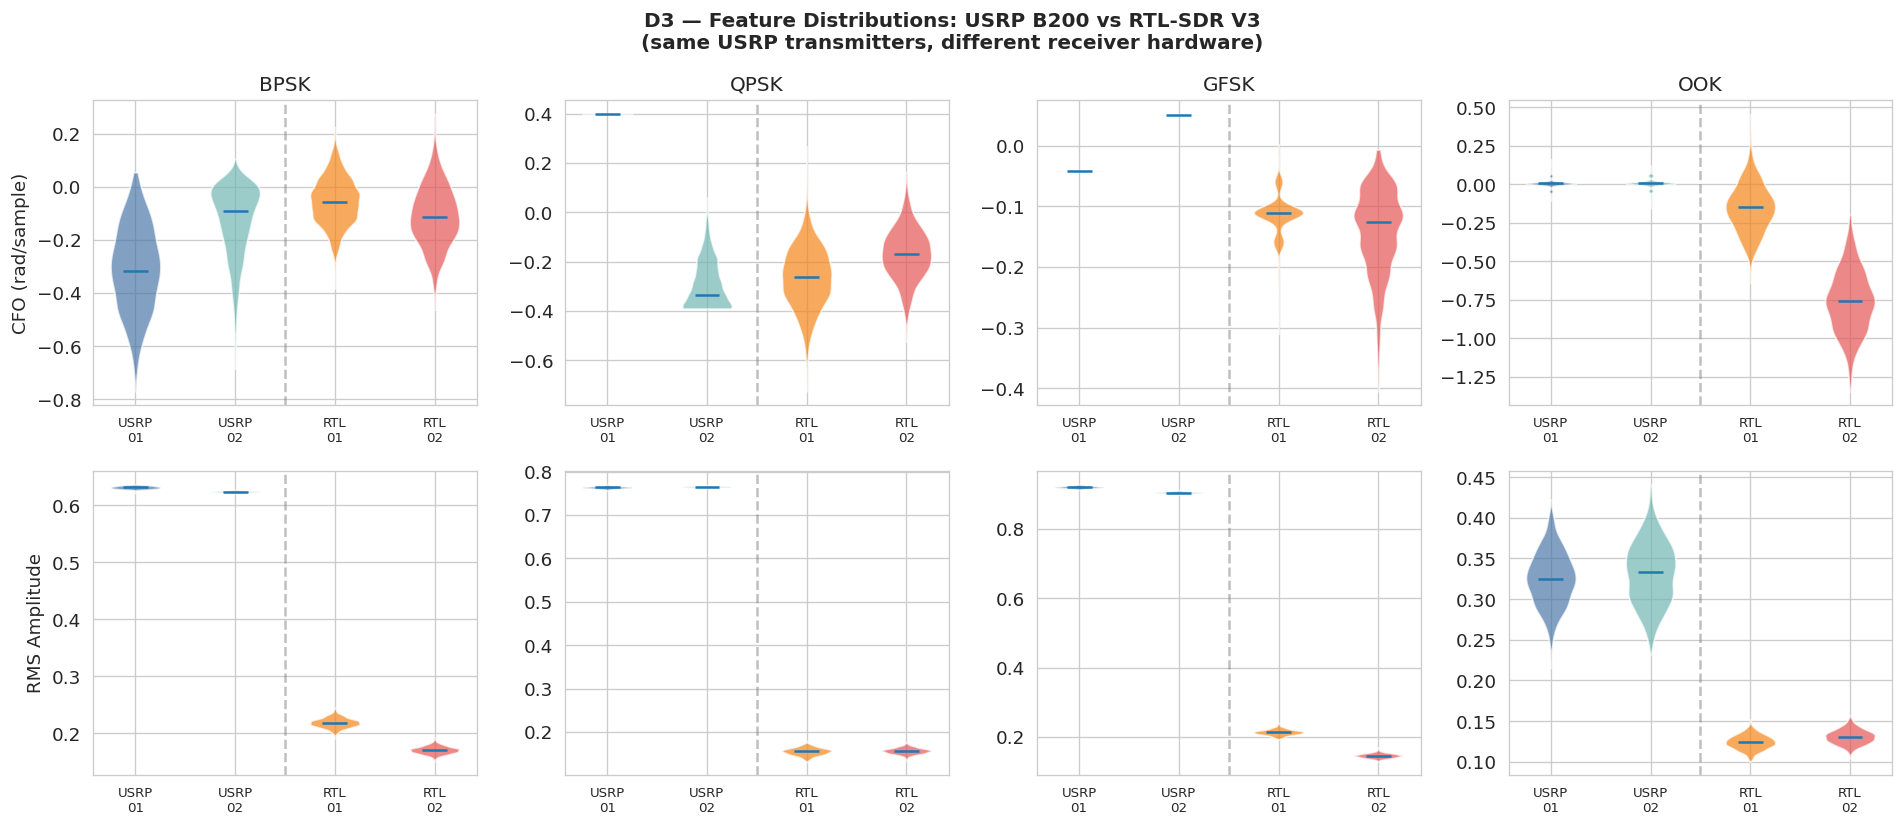

Figure saved: D3_feature_distributions.pdf


In [ ]:
def extract_features(fpath, n_segs=800):
    """Extract CFO (inst-freq mean) and RMS per window."""
    iq = np.fromfile(fpath, dtype=np.complex64)[TRANSIENT:]
    peak = np.max(np.abs(iq))
    if peak > 0: iq /= peak
    n = min(len(iq)//WIN_SIZE, n_segs)
    cfos, rmss = [], []
    for i in range(n):
        seg = iq[i*WIN_SIZE:(i+1)*WIN_SIZE]
        phase = np.angle(seg)
        cfos.append(float(np.mean(np.diff(np.unwrap(phase)))))
        rmss.append(float(np.sqrt(np.mean(np.abs(seg)**2))))
    return np.array(cfos), np.array(rmss)

feat = {}  # feat[(hw, dev, mod)] = {'cfo': arr, 'rms': arr}
for mod in MODS:
    for dev in DEVICES:
        # USRP S1 R1
        usrp_f = os.path.join(USRP_DATA_DIR, f'{dev}_{mod}_S1_R1.dat')
        if os.path.exists(usrp_f):
            c, r = extract_features(usrp_f)
            feat[('USRP', dev, mod)] = {'cfo': c, 'rms': r}
        else:
            print(f'  MISSING USRP: {dev}_{mod}_S1_R1.dat')
        # RTL S3 R1
        sel = df_manifest[(df_manifest.device==dev)&(df_manifest.modulation==mod)&(df_manifest.rep==1)]
        if not sel.empty:
            c, r = extract_features(sel.iloc[0]['file'])
            feat[('RTL', dev, mod)] = {'cfo': c, 'rms': r}

print(f'Features extracted for {len(feat)} file combinations.')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('D3 — Feature Distributions: USRP B200 vs RTL-SDR V3\n'
             '(same USRP transmitters, different receiver hardware)', fontsize=12, fontweight='bold')
colors = {'USRP_DEV01':'#4C78A8','USRP_DEV02':'#72B7B2',
          'RTL_DEV01': '#F58518','RTL_DEV02': '#E45756'}

for col, mod in enumerate(MODS):
    for row_idx, feat_key in enumerate(['cfo','rms']):
        ax = axes[row_idx, col]
        vdata, vlabels = [], []
        for hw in ['USRP','RTL']:
            for dev in DEVICES:
                k = (hw, dev, mod)
                if k in feat:
                    vdata.append(feat[k][feat_key])
                    vlabels.append(f'{hw}\n{dev[-2:]}')
        vp = ax.violinplot(vdata, showmedians=True, showextrema=False)
        for patch, c in zip(vp['bodies'], list(colors.values())):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_xticks(range(1,len(vlabels)+1))
        ax.set_xticklabels(vlabels, fontsize=8)
        ax.axvline(2.5, color='gray', ls='--', alpha=0.5)
        if row_idx == 0: ax.set_title(mod)
        if col == 0:
            ax.set_ylabel('CFO (rad/sample)' if row_idx==0 else 'RMS Amplitude')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/D3_feature_distributions.pdf', bbox_inches='tight'); plt.show()
print('Figure saved: D3_feature_distributions.pdf')

## Cell 12 — D3: t-SNE Embedding (CNN Penultimate Layer)
> Projects Model B1's Dense(64) embeddings for both USRP and RTL-SDR windows.
> If USRP and RTL clusters are spatially separated for the same device, it confirms
> the model learned receiver-coloured features, not purely transmitter fingerprints.

Embedding model ready.
Layer names in model_b1: ['iq_input', 'conv1d', 'average_pooling1d', 'conv1d_1', 'average_pooling1d_1', 'conv1d_2', 'average_pooling1d_2', 'global_average_pooling1d', 'dense', 'dropout', 'dense_1']

Extracting RTL-SDR embeddings...
  RTL-SDR: 24,000 embeddings collected
Extracting USRP embeddings...
  MISSING: DEV01_BPSK_S2_R1.dat — skipping
  MISSING: DEV02_BPSK_S2_R1.dat — skipping
  MISSING: DEV01_QPSK_S2_R1.dat — skipping
  MISSING: DEV02_QPSK_S2_R1.dat — skipping
  MISSING: DEV01_GFSK_S2_R1.dat — skipping
  MISSING: DEV02_GFSK_S2_R1.dat — skipping
  MISSING: DEV01_OOK_S2_R1.dat — skipping
  MISSING: DEV02_OOK_S2_R1.dat — skipping
  USRP: 0 files found

No USRP S2 R1 files found.
Plotting RTL-SDR embeddings only (coloured by device).

Total embeddings for t-SNE: 24,000
  USRP:    0
  RTL-SDR: 24,000
Running t-SNE (may take 2–4 minutes)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 24000 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 24000 samples in 7.118s...
[t-SNE] Computed conditional probabilities for sample 1000 / 24000
[t-SNE] Computed conditional probabilities for sample 2000 / 24000
[t-SNE] Computed conditional probabilities for sample 3000 / 24000
[t-SNE] Computed conditional probabilities for sample 4000 / 24000
[t-SNE] Computed conditional probabilities for sample 5000 / 24000
[t-SNE] Computed conditional probabilities for sample 6000 / 24000
[t-SNE] Computed conditional probabilities for sample 7000 / 24000
[t-SNE] Computed conditional probabilities for sample 8000 / 24000
[t-SNE] Computed conditional probabilities for sample 9000 / 24000
[t-SNE] Computed conditional probabilities for sample 10000 / 24000
[t-SNE] Computed conditional probabilities for sample 11000 / 24000
[t-SNE] Computed conditional probabilities for sample 12000 / 24000
[t-SNE] Computed conditional probabilities for sample 13000 / 24000
[t-SNE] Computed conditional probabilities for sample 14000 / 24000

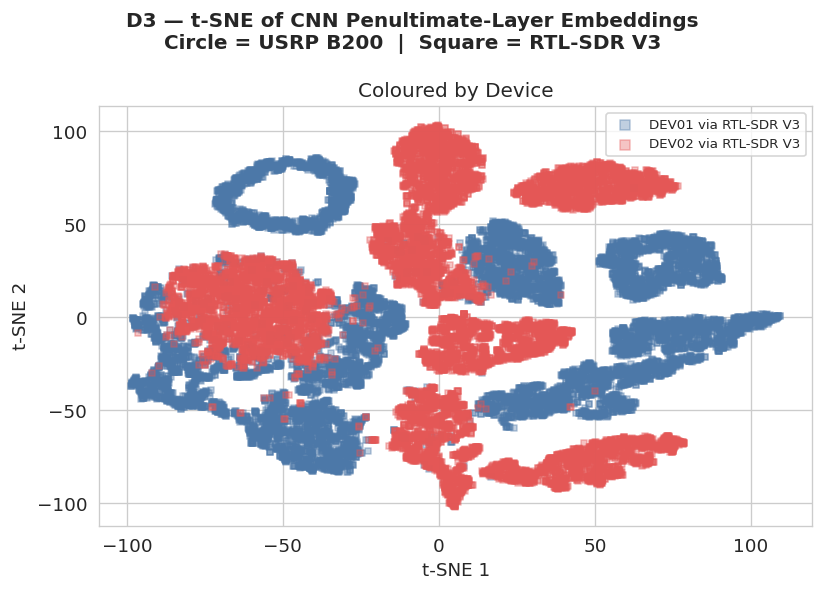

Figure saved: D3_tsne_embeddings.pdf


In [ ]:
# ── Cell 12 — D3: t-SNE Embedding (CNN Penultimate Layer) ────────────────────

# Use 'dense' (Dense-64 layer) — the actual name in the loaded model_b1
emb_model = Model(inputs=model_b1.input,
                   outputs=model_b1.get_layer('dense').output)

print('Embedding model ready.')
print('Layer names in model_b1:', [l.name for l in model_b1.layers])

N_PER_CLASS = 1500  # per class per hardware — keeps t-SNE fast
emb_all, dev_all, hw_all = [], [], []

# ── RTL-SDR embeddings (test files R4+R5) ────────────────────────────────────
print('\nExtracting RTL-SDR embeddings...')
for row in test_rows:
    X = load_windows(row['file'])[:N_PER_CLASS]
    e = emb_model.predict(X, batch_size=512, verbose=0)
    emb_all.append(e)
    dev_all.append(np.full(len(e), row['label'], dtype=int))
    hw_all.append(np.ones(len(e),  dtype=int))   # 1 = RTL-SDR
    del X, e; gc.collect()
print(f'  RTL-SDR: {sum(len(e) for e in emb_all):,} embeddings collected')

# ── USRP embeddings (S2 R1 files as reference) ───────────────────────────────
print('Extracting USRP embeddings...')
usrp_found = 0
for mod in MODS:
    for dev in DEVICES:
        usrp_f = os.path.join(USRP_DATA_DIR, f'{dev}_{mod}_S2_R1.dat')
        if not os.path.exists(usrp_f):
            print(f'  MISSING: {dev}_{mod}_S2_R1.dat — skipping')
            continue
        X = load_windows(usrp_f)[:N_PER_CLASS]
        e = emb_model.predict(X, batch_size=512, verbose=0)
        emb_all.append(e)
        dev_all.append(np.full(len(e), LABEL_MAP[dev], dtype=int))
        hw_all.append(np.zeros(len(e), dtype=int))  # 0 = USRP
        usrp_found += 1
        del X, e; gc.collect()
print(f'  USRP: {usrp_found} files found')

if usrp_found == 0:
    print('\nNo USRP S2 R1 files found.')
    print('Plotting RTL-SDR embeddings only (coloured by device).')

# ── Combine and run t-SNE ─────────────────────────────────────────────────────
emb_all = np.concatenate(emb_all)
dev_all = np.concatenate(dev_all)
hw_all  = np.concatenate(hw_all)
print(f'\nTotal embeddings for t-SNE: {len(emb_all):,}')
print(f'  USRP:    {(hw_all==0).sum():,}')
print(f'  RTL-SDR: {(hw_all==1).sum():,}')

print('Running t-SNE (may take 2–4 minutes)...')
tsne   = TSNE(n_components=2, perplexity=30, n_iter=1000,
              random_state=SEED, verbose=1)
emb_2d = tsne.fit_transform(emb_all)

# ── Plot ──────────────────────────────────────────────────────────────────────
n_panels = 2 if usrp_found > 0 else 1
fig, axes = plt.subplots(1, n_panels, figsize=(7*n_panels, 5))
if n_panels == 1:
    axes = [axes]

fig.suptitle('D3 — t-SNE of CNN Penultimate-Layer Embeddings\n'
             'Circle = USRP B200  |  Square = RTL-SDR V3',
             fontsize=12, fontweight='bold')

dev_colors = {0: '#4C78A8', 1: '#E45756'}
hw_markers = {0: 'o',       1: 's'}
hw_names   = {0: 'USRP B200', 1: 'RTL-SDR V3'}
dev_names  = {0: 'DEV01',     1: 'DEV02'}

plot_configs = [('Coloured by Device',    'device'),
                ('Coloured by Hardware',  'hardware')]

for ax, (title, color_by) in zip(axes, plot_configs):
    for hw in [0, 1]:
        for dev in [0, 1]:
            mask = (hw_all == hw) & (dev_all == dev)
            if not mask.any():
                continue
            c = dev_colors[dev] if color_by == 'device' \
                else ('#4C78A8' if hw == 0 else '#E45756')
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                       c=c, marker=hw_markers[hw],
                       s=10, alpha=0.35,
                       label=f'{dev_names[dev]} via {hw_names[hw]}')
    ax.set_title(title)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/D3_tsne_embeddings.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: D3_tsne_embeddings.pdf')

In [ ]:
# Find where USRP S2 files are stored
import glob

search_roots = [
    '/content/drive/MyDrive/My Thesis/Recordings',
    '/content/drive/MyDrive/My Thesis/Recordings/Recordings_Mod',
    '/content/drive/MyDrive/My Thesis/Recordings/Recordings_Mod/S2',
    '/content/drive/MyDrive/My Thesis',
]

print('Searching for USRP .dat files...')
found = []
for root in search_roots:
    hits = glob.glob(os.path.join(root, '**', '*.dat'), recursive=True)
    found.extend(hits)

found = sorted(set(found))
print(f'Found {len(found)} .dat files:\n')
for f in found[:40]:  # show first 40
    print(f'  {f}')
if len(found) > 40:
    print(f'  ... and {len(found)-40} more')

Searching for USRP .dat files...
Found 142 .dat files:

  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV01_QPSK_S3_R1.dat
  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV01_QPSK_S3_R2.dat
  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV01_QPSK_S3_R3.dat
  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV01_QPSK_S3_R4.dat
  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV01_QPSK_S3_R5.dat
  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV02_QPSK_S3_R1.dat
  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV02_QPSK_S3_R2.dat
  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV02_QPSK_S3_R3.dat
  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV02_QPSK_S3_R4.dat
  /content/drive/MyDrive/My Thesis/Recordings/Recordings_GNU_Improved/DEV02_QPSK_S3_R5.dat
  /content/drive/MyDrive/My Thesis

Extracting RTL-SDR embeddings...
  RTL-SDR: 24,000 embeddings
Extracting USRP embeddings...
  USRP: 8 files loaded

Total embeddings: 36,000
  USRP    : 12,000
  RTL-SDR : 24,000

Running t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 36000 samples in 0.001s...
[t-SNE] Computed neighbors for 36000 samples in 12.661s...
[t-SNE] Computed conditional probabilities for sample 1000 / 36000
[t-SNE] Computed conditional probabilities for sample 2000 / 36000
[t-SNE] Computed conditional probabilities for sample 3000 / 36000
[t-SNE] Computed conditional probabilities for sample 4000 / 36000
[t-SNE] Computed conditional probabilities for sample 5000 / 36000
[t-SNE] Computed conditional probabilities for sample 6000 / 36000
[t-SNE] Computed conditional probabilities for sample 7000 / 36000
[t-SNE] Computed conditional probabilities for sample 8000 / 36000
[t-SNE] Computed conditional probabilities for sample 9000 / 36000
[t-SNE] Computed conditional probabilities for sample 10

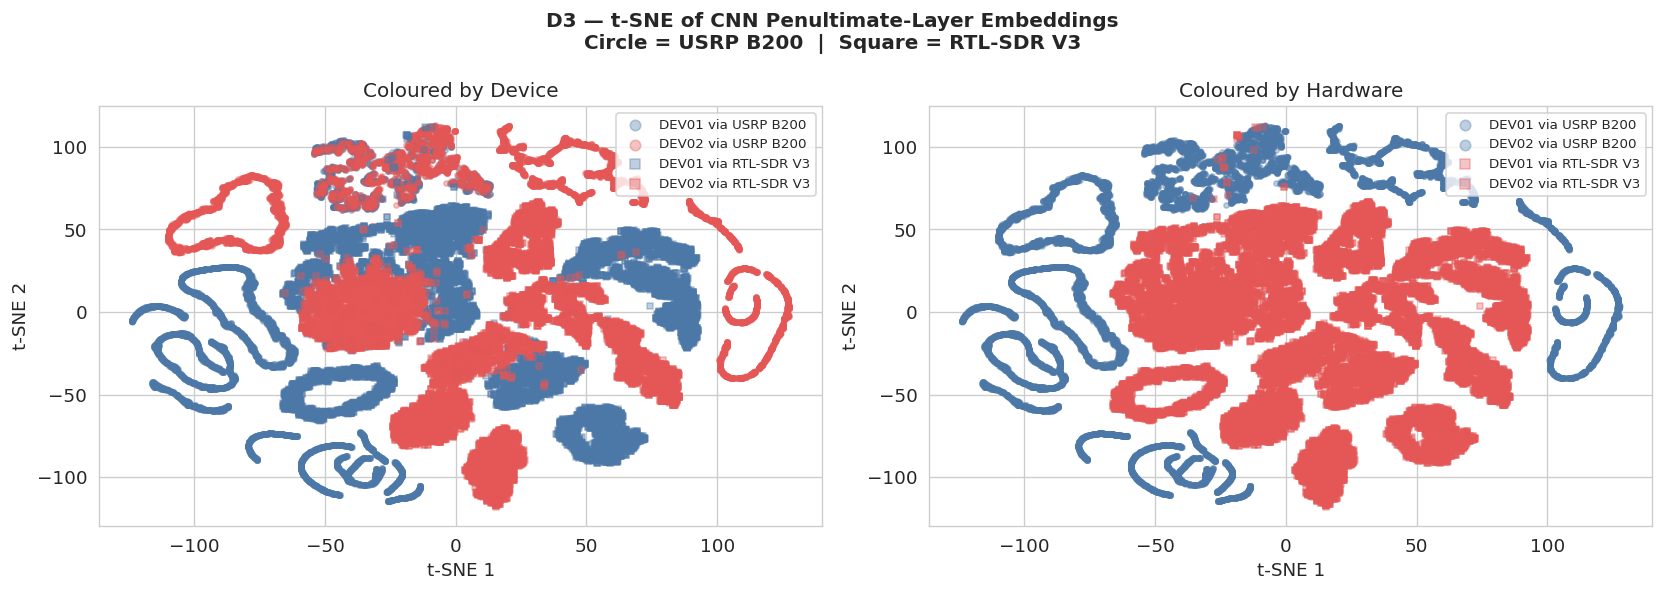

Figure saved: D3_tsne_embeddings.pdf


In [ ]:
# ── Cell 12 — D3: t-SNE (FIXED — uses USRP S1 R1 files) ─────────────────────

USRP_DATA_DIR = '/content/drive/MyDrive/My Thesis/Recordings/Recordings_Mod'

emb_model = Model(inputs=model_b1.input,
                   outputs=model_b1.get_layer('dense').output)

N_PER_CLASS = 1500
emb_all, dev_all, hw_all = [], [], []

# ── RTL-SDR embeddings (test files R4+R5) ────────────────────────────────────
print('Extracting RTL-SDR embeddings...')
for row in test_rows:
    X = load_windows(row['file'])[:N_PER_CLASS]
    e = emb_model.predict(X, batch_size=512, verbose=0)
    emb_all.append(e)
    dev_all.append(np.full(len(e), row['label'], dtype=int))
    hw_all.append(np.ones(len(e), dtype=int))   # 1 = RTL-SDR
    del X, e; gc.collect()
print(f'  RTL-SDR: {(np.concatenate(hw_all)==1).sum():,} embeddings')

# ── USRP embeddings (S1 R1 — fixed path) ─────────────────────────────────────
print('Extracting USRP embeddings...')
usrp_found = 0
for mod in MODS:
    for dev in DEVICES:
        usrp_f = os.path.join(USRP_DATA_DIR, f'{dev}_{mod}_S1_R1.dat')  # S1 not S2
        if not os.path.exists(usrp_f):
            print(f'  MISSING: {os.path.basename(usrp_f)}')
            continue
        X = load_windows(usrp_f)[:N_PER_CLASS]
        e = emb_model.predict(X, batch_size=512, verbose=0)
        emb_all.append(e)
        dev_all.append(np.full(len(e), LABEL_MAP[dev], dtype=int))
        hw_all.append(np.zeros(len(e), dtype=int))  # 0 = USRP
        usrp_found += 1
        del X, e; gc.collect()
print(f'  USRP: {usrp_found} files loaded')

# ── Combine ───────────────────────────────────────────────────────────────────
emb_all = np.concatenate(emb_all)
dev_all = np.concatenate(dev_all)
hw_all  = np.concatenate(hw_all)
print(f'\nTotal embeddings: {len(emb_all):,}')
print(f'  USRP    : {(hw_all==0).sum():,}')
print(f'  RTL-SDR : {(hw_all==1).sum():,}')

# ── t-SNE ─────────────────────────────────────────────────────────────────────
print('\nRunning t-SNE...')
tsne   = TSNE(n_components=2, perplexity=30, max_iter=1000,
              random_state=SEED, verbose=1)
emb_2d = tsne.fit_transform(emb_all)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('D3 — t-SNE of CNN Penultimate-Layer Embeddings\n'
             'Circle = USRP B200  |  Square = RTL-SDR V3',
             fontsize=12, fontweight='bold')

dev_colors = {0: '#4C78A8', 1: '#E45756'}
hw_markers = {0: 'o',       1: 's'}
hw_names   = {0: 'USRP B200', 1: 'RTL-SDR V3'}
dev_names  = {0: 'DEV01',     1: 'DEV02'}

for ax, (title, color_by) in zip(axes, [
        ('Coloured by Device',   'device'),
        ('Coloured by Hardware', 'hardware')]):
    for hw in [0, 1]:
        for dev in [0, 1]:
            mask = (hw_all == hw) & (dev_all == dev)
            if not mask.any():
                continue
            c = dev_colors[dev] if color_by == 'device' \
                else ('#4C78A8' if hw == 0 else '#E45756')
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                       c=c, marker=hw_markers[hw],
                       s=10, alpha=0.35,
                       label=f'{dev_names[dev]} via {hw_names[hw]}')
    ax.set_title(title)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/D3_tsne_embeddings.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: D3_tsne_embeddings.pdf')

## Cell 13 — Bootstrap CI + SQ4 Summary Answer

In [ ]:
# Bootstrap 95% CI on D1 accuracy per modulation (Clean condition)
def bootstrap_ci(labels, probs, n_boot=1000):
    n = len(labels)
    accs = [accuracy_score(labels[idx:=np.random.randint(0,n,n)],
                            (probs[idx]>=0.5).astype(int))*100
            for _ in range(n_boot)]
    return round(np.percentile(accs,2.5),2), round(np.percentile(accs,97.5),2)

print('=== Bootstrap 95% CI on D1 Zero-Shot Accuracy (Clean) ===')
print(f'{"Modulation":8s}  {"Acc":>8s}  {"95% CI":>20s}  {"FAR":>8s}')
for mod in MODS:
    r   = d1_per_mod[mod][0]  # Clean condition
    lo, hi = bootstrap_ci(r['labels'], r['probs'])
    print(f'{mod:8s}  {r["accuracy"]:>7.2f}%  [{lo:.2f}%, {hi:.2f}%]  {r["far"]:>7.3f}%')

print()
print('='*65)
print('SQ4 ANSWER SUMMARY')
print('Q: How much does USRP B200 → RTL-SDR V3 deployment degrade accuracy?')
print('='*65)
print()
print('Zero-shot domain gap (dAcc) at Clean:')
for _, row in clean_gaps.iterrows():
    direction = 'degradation' if row['dAcc']>0 else 'improvement'
    print(f"  {row['Modulation']:6s}: {row['Acc_USRP']:.1f}% → "
          f"{row['Acc_RTL_D1']:.1f}%  (dAcc = {row['dAcc']:+.1f} pp {direction})")
print(f"\n  Mean dAcc: {clean_gaps['dAcc'].mean():+.2f} pp")
print()
print('RTL-SDR in-domain ceiling vs zero-shot (Clean):')
for mod in MODS:
    d1c = d1_per_mod[mod][0]['accuracy']
    d2c = d2_per_mod[mod][0]['accuracy']
    print(f'  {mod:6s}: ZeroShot={d1c:.1f}%  InDomain={d2c:.1f}%  '
          f'(recoverable: {d2c-d1c:+.1f} pp)')
print()
print('Note: D2 is a within-session split (R1-R3 train / R4-R5 test).')
print('It represents an optimistic upper bound on RTL-SDR performance.')

=== Bootstrap 95% CI on D1 Zero-Shot Accuracy (Clean) ===
Modulation       Acc                95% CI       FAR
BPSK        49.41%  [49.31%, 49.53%]   99.952%
QPSK        71.66%  [71.55%, 71.77%]   43.279%
GFSK        27.89%  [27.79%, 28.00%]   54.528%
OOK         49.78%  [49.66%, 49.90%]    0.595%

SQ4 ANSWER SUMMARY
Q: How much does USRP B200 → RTL-SDR V3 deployment degrade accuracy?

Zero-shot domain gap (dAcc) at Clean:
  BPSK  : 100.0% → 49.4%  (dAcc = +50.6 pp degradation)
  QPSK  : 100.0% → 71.7%  (dAcc = +28.3 pp degradation)
  GFSK  : 100.0% → 27.9%  (dAcc = +72.1 pp degradation)
  OOK   : 70.5% → 49.8%  (dAcc = +20.7 pp degradation)

  Mean dAcc: +42.94 pp

RTL-SDR in-domain ceiling vs zero-shot (Clean):
  BPSK  : ZeroShot=49.4%  InDomain=99.5%  (recoverable: +50.1 pp)
  QPSK  : ZeroShot=71.7%  InDomain=91.3%  (recoverable: +19.6 pp)
  GFSK  : ZeroShot=27.9%  InDomain=99.9%  (recoverable: +72.0 pp)
  OOK   : ZeroShot=49.8%  InDomain=96.4%  (recoverable: +46.6 pp)

Note: D2 is 

## Cell 14 — Final Summary Figure

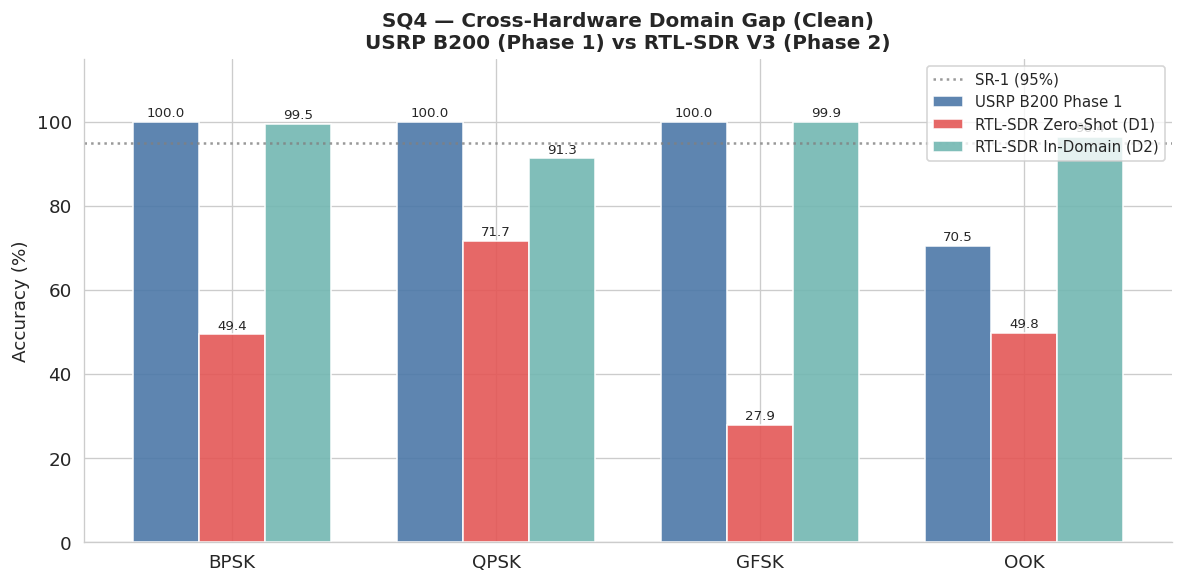

Figure saved: SQ4_summary_bar_chart.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(MODS)); w = 0.25
tgt = 'Clean'

acc_u = [PHASE1_ACC[m][tgt] for m in MODS]
acc_d1 = [d1_per_mod[m][SNR_LABELS.index(tgt)]['accuracy'] for m in MODS]
acc_d2 = [d2_per_mod[m][SNR_LABELS.index(tgt)]['accuracy'] for m in MODS]

b1 = ax.bar(x-w, acc_u,  w, label='USRP B200 Phase 1',      color='#4C78A8', alpha=0.9)
b2 = ax.bar(x,   acc_d1, w, label='RTL-SDR Zero-Shot (D1)',  color='#E45756', alpha=0.9)
b3 = ax.bar(x+w, acc_d2, w, label='RTL-SDR In-Domain (D2)',  color='#72B7B2', alpha=0.9)
for bars in [b1,b2,b3]:
    for bar in bars:
        h = bar.get_height()
        if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.5,
                        f'{h:.1f}', ha='center', va='bottom', fontsize=8)
ax.axhline(95, color='gray', ls=':', alpha=0.8, label='SR-1 (95%)')
ax.set_xticks(x); ax.set_xticklabels(MODS, fontsize=11)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0,115)
ax.set_title(f'SQ4 — Cross-Hardware Domain Gap ({tgt})\n'
             'USRP B200 (Phase 1) vs RTL-SDR V3 (Phase 2)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); sns.despine()
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/SQ4_summary_bar_chart.pdf', bbox_inches='tight')
plt.show()
print('Figure saved: SQ4_summary_bar_chart.pdf')

## Cell 15 — Save All Results

In [ ]:
# Save D2 model
model_d2.save(os.path.join(OUT_DIR,'model_d2_rtl_indomain.keras'))

# Save JSON summary
results = {
    'experiment': 'SQ4_domain_gap',
    'capture_params': {'fc_hz':900e6,'fs_hz':1e6,'tx_gain':30,
                       'rtl_rf_gain':30,'rtl_if_gain':20,'rtl_bb_gain':20,
                       'agc':False,'dc_offset_mode':0,'iq_balance_mode':0},
    'split': {'train_reps':TRAIN_REPS,'test_reps':TEST_REPS},
    'phase1_reference': PHASE1_ACC,
    'D1_zeroshot': {m:{SNR_LABELS[i]:r['accuracy']
                       for i,r in enumerate(d1_per_mod[m])} for m in MODS},
    'D2_indomain': {m:{SNR_LABELS[i]:r['accuracy']
                       for i,r in enumerate(d2_per_mod[m])} for m in MODS},
    'dAcc_clean':  {row['Modulation']:row['dAcc']
                    for _,row in clean_gaps.iterrows()},
    'mean_dAcc_clean': round(clean_gaps['dAcc'].mean(),2)
}
with open(os.path.join(OUT_DIR,'SQ4_results.json'),'w') as f:
    json.dump(results, f, indent=2)

print('=== All outputs saved to:', OUT_DIR, '===')
for fn in sorted(os.listdir(OUT_DIR)):
    print(' ', fn)
print('figures/')
for fn in sorted(os.listdir(FIG_DIR)):
    print('   ', fn)

=== All outputs saved to: /content/drive/MyDrive/My Thesis/SQ4_Results ===
  SQ4_comparison_table.csv
  SQ4_results.json
  dAcc_domain_gap_table.csv
  figures
  model_d2_rtl_indomain.keras
figures/
    C_rtl_quality_check.pdf
    D1_accuracy_snr_curves.pdf
    D1_confusion_matrices.pdf
    D1_dacc_heatmap.pdf
    D2_training_curve.pdf
    D3_feature_distributions.pdf
    D3_tsne_embeddings.pdf
    SQ4_summary_bar_chart.pdf
    SQ4_three_way_heatmaps.pdf


In [2]:
# Convert all PDFs → PNG, save back to Drive
import os, subprocess
subprocess.run(['apt-get', 'install', '-y', '-q', 'poppler-utils'])
subprocess.run(['pip', 'install', 'pdf2image', '-q'])
from pdf2image import convert_from_path

FIG_SRC = '/content/drive/MyDrive/My Thesis/SQ4_Results/figures'
FIG_PNG = '/content/drive/MyDrive/My Thesis/SQ4_Results/figures_png'
os.makedirs(FIG_PNG, exist_ok=True)

for f in sorted(os.listdir(FIG_SRC)):
    if f.endswith('.pdf'):
        pages = convert_from_path(os.path.join(FIG_SRC, f), dpi=150)
        out = f.replace('.pdf', '.png')
        pages[0].save(os.path.join(FIG_PNG, out), 'PNG')
        print(f'✓  {out}')

print(f'\nDone. 9 PNGs saved to:\n{FIG_PNG}')

✓  C_rtl_quality_check.png
✓  D1_accuracy_snr_curves.png
✓  D1_confusion_matrices.png
✓  D1_dacc_heatmap.png
✓  D2_training_curve.png
✓  D3_feature_distributions.png
✓  D3_tsne_embeddings.png
✓  SQ4_summary_bar_chart.png
✓  SQ4_three_way_heatmaps.png

Done. 9 PNGs saved to:
/content/drive/MyDrive/My Thesis/SQ4_Results/figures_png
